# Exercise: Neural Networks

## 1. Import the required libraries in the cell below

In [1]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

## 2. Read the data

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


## 3. Conduct Exploratory Data Analysis 

In [3]:
# Check data info
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    str    
 1   city       985 non-null    str    
 2   zip        985 non-null    int64  
 3   state      985 non-null    str    
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    str    
 8   sale_date  985 non-null    str    
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), str(5)
memory usage: 92.5 KB


In [4]:
# Check for missing values
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [5]:
# Check data types
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [6]:
# Look at the Summary Stats.
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [7]:
# Cleaning Steps (if needed)
housing = housing[housing['sq__ft'] > 0]

In [8]:
housing.duplicated().sum()

np.int64(2)

In [9]:
housing = housing.drop_duplicates()

In [10]:
housing.duplicated().sum()

np.int64(0)

In [11]:
housing.shape

(811, 12)

## 4. Split the Data & Pre-Processing
**Best Practice for Neural Network** Split your data before modeling into three part:

1. __The Training Set (The Textbook):__ This is the data the neural network actually looks at to learn. During the training loop, the network uses this data to adjust its **weights** and **biases** via backpropagation.

2. __The Validation Set (The Practice Quiz):__ This data evaluates the model *during* training to fine-tune settings. The model does not learn its weights from this data. Instead, the it uses the validation score to choose **hyperparameters** (like learning rate, number of layers, or node count) and to decide when to stop training (**early stopping**).


3. __The Test Set (The Final Exam):__ This data provides an unbiased, final evaluation of the model's real-world performance. This dataset is locked away until training is completely finished. It is only used *once* at the very end to see how well the network performs on truly unseen data.

__Typical Split Ratios__

Depending on the size of your total dataset, data scientists generally use these proportions:

| Dataset Size | Train | Validation | Test |
| :--- | :--- | :--- | :--- |
| **Traditional (Small/Medium Data)** | 60% | 20% | 20% |
| **Modern Deep Learning (Millions of Rows)** | 98% | 1% | 1% |

In [12]:
# Select the Features and Target
X = housing[['sq__ft']]
y = housing['price']

In [13]:
# Split to Train Test & Validation
X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.20,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all,test_size=0.20, random_state=42)

In [14]:
# IMPORTANT: Scale the features for Neural Networks
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_val_scaled = ss.transform(X_val)
X_test_scaled = ss.transform(X_test)

## 5. Linear Regression

In [15]:
# Initialize LinearRegression model
# Initialize LinearRegression model
lr = LinearRegression()

In [16]:
# Fit and check the Training Score
lr.fit(X_train_scaled,y_train)
print(lr.score(X_train_scaled,y_train))

0.44846417256742943


In [17]:
# Predict and check the Testing Score
y_pred = lr.predict(X_test_scaled)
lr.score(X_test_scaled, y_test)

0.5476197770333637

In [18]:
# Evaluate the model
# Coefficient 
print(lr.coef_)
# Intercept
print(lr.intercept_)
# RMSE
print(root_mean_squared_error(y_test,y_pred))

[82568.6949645]
234511.44208494207
74987.14988237318


## 6. Build a Single Neural Network
Creating a model in `keras` entails a few steps:
1. Create your network topology
2. Compile your model
3. Fit your model
   
**Important Note on Regression:**
Because we are predicting a continuous value (house price), our network is performing regression, not classification. 
* Your **hidden layers** should generally use the `relu` activation function.
* Your **output layer** must have exactly **1 neuron** and **no activation function** (or `activation='linear'`) so it can predict any continuous number.
* When compiling, use `loss='mse'` (Mean Squared Error) and `metrics=['mae']` (Mean Absolute Error) so we can see the error in actual dollar amounts.

In [19]:
# Step 1: Define
model=Sequential()

model.add(Input(shape=(1,)))
model.add(Dense(1,activation='linear'))


# Step 2: Compile 
model.compile(loss='mse' , metrics=['mae'])


# Step 3: Fit
model.fit(X_train_scaled, y_train,validation_data=(X_val_scaled, y_val), epochs=100, verbose=1)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 70197690368.0000 - mae: 234511.3906 - val_loss: 62151553024.0000 - val_mae: 221362.3438
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197673984.0000 - mae: 234511.3906 - val_loss: 62151553024.0000 - val_mae: 221362.3438
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197665792.0000 - mae: 234511.3750 - val_loss: 62151540736.0000 - val_mae: 221362.3281
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197657600.0000 - mae: 234511.3906 - val_loss: 62151532544.0000 - val_mae: 221362.3125
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197649408.0000 - mae: 234511.3594 - val_loss: 62151524352.0000 - val_mae: 221362.2812
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197633024.0000 - mae: 234511.3281 - val_loss: 62151516160.0000 - val_mae: 221362.2812
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197633024.0000 - mae: 234511.3281 - val_loss: 6215150796

In [20]:
# Model Weights
model.weights

[<Variable path=sequential/dense/kernel, shape=(1, 1), dtype=float32, value=[[1.2619127]]>,
 <Variable path=sequential/dense/bias, shape=(1,), dtype=float32, value=[1.6988173]>]

In [21]:
# Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6 (28.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4 (20.00 B)

## 7. Stacking Multiple Neurons

#### Shallow NN

In [22]:
# Step 1: Define
model_1= Sequential()
model_1.add(Input(shape=(1,))) 
model_1.add(Dense(3))  
model_1.add(Dense(1)) 

# Step 2: Compile 
model_1.compile(loss='mse' , metrics=['mae'])


# Step 3: Fit
model_1.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val),  epochs=100, verbose=1)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 70197714944.0000 - mae: 234511.4062 - val_loss: 62151561216.0000 - val_mae: 221362.2812
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197673984.0000 - mae: 234511.3281 - val_loss: 62151532544.0000 - val_mae: 221362.2188
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197633024.0000 - mae: 234511.2969 - val_loss: 62151491584.0000 - val_mae: 221362.1562
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197600256.0000 - mae: 234511.2500 - val_loss: 62151462912.0000 - val_mae: 221362.1094
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197559296.0000 - mae: 234511.1406 - val_loss: 62151430144.0000 - val_mae: 221362.0625
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197534720.0000 - mae: 234511.0781 - val_loss: 62151393280.0000 - val_mae: 221362.0000
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197501952.0000 - mae: 234511.0156 - val_loss: 6215136870

In [23]:
# Model Weights
model_1.weights

[<Variable path=sequential_1/dense_1/kernel, shape=(1, 3), dtype=float32, value=[[-1.4099679  0.6334639  1.5417833]]>,
 <Variable path=sequential_1/dense_1/bias, shape=(3,), dtype=float32, value=[-1.70785    1.7067884  1.7104528]>,
 <Variable path=sequential_1/dense_2/kernel, shape=(3, 1), dtype=float32, value=[[-2.5410151]
  [ 2.3182492]
  [ 2.1993356]]>,
 <Variable path=sequential_1/dense_2/bias, shape=(1,), dtype=float32, value=[1.6986241]>]

In [24]:
# Model Summary
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 3)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

#### Deep Network

In [25]:
# use multiple hidden layers with different neurons

# Step 1: Define
model_2 = Sequential()
model_2.add(Dense(30)) 
model_2.add(Dense(20))
model_2.add(Dense(15))
model_2.add(Dense(1))

# Step 2: Compile 
model_2.compile(loss='mse', metrics=['mae'])


# Step 3: Fit
model_2.fit(X_train_scaled, y_train,
          validation_data=(X_val_scaled, y_val), epochs=100, verbose=1)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 70197436416.0000 - mae: 234511.1562 - val_loss: 62151147520.0000 - val_mae: 221361.9062
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70196879360.0000 - mae: 234510.4375 - val_loss: 62150565888.0000 - val_mae: 221361.2656
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70196084736.0000 - mae: 234509.4531 - val_loss: 62149754880.0000 - val_mae: 221360.1562
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70194880512.0000 - mae: 234507.8281 - val_loss: 62148476928.0000 - val_mae: 221358.4375
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 70193143808.0000 - mae: 234505.3281 - val_loss: 62146711552.0000 - val_mae: 221355.9219
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70190825472.0000 - mae: 234501.9531 - val_loss: 62144475136.0000 - val_mae: 221352.5312
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70187753472.0000 - mae: 234497.3750 - val_loss: 6214136217

In [26]:
# Model Weights
model_2.weights

[<Variable path=sequential_2/dense_3/kernel, shape=(1, 30), dtype=float32, value=[[ 1.527959   -1.2890339   1.05294    -1.5474257   0.927067   -1.2893089
   -1.521427    1.0123266   1.5319587   1.48363     1.0660098  -1.496432
    1.0501666  -0.98131704 -1.4262031   1.3822572  -1.4360772  -1.4819182
   -1.3575045  -0.89005446  1.1736672   1.2548442  -1.1985905   1.269977
    1.5583788  -1.5699668   1.5055096   1.4556259   1.4439704  -1.2080414 ]]>,
 <Variable path=sequential_2/dense_3/bias, shape=(30,), dtype=float32, value=[ 1.7652888 -1.6946765  1.7726669 -1.7653105  1.7627708 -1.7691596
  -1.7654697  1.7630789  1.7091529  1.7662903  1.77194   -1.7214621
   1.7625796 -1.7724159 -1.7703025  1.7618585 -1.7709622 -1.7662953
  -1.6578026 -1.7618864  1.7766733  1.7676125 -1.7714453  1.7749048
   1.760261  -1.765073   1.7656949  1.7531066  1.7646706 -1.7700323]>,
 <Variable path=sequential_2/dense_4/kernel, shape=(30, 20), dtype=float32, value=[[-1.5894575 -1.4474804 -1.405555   1.6862551 

In [27]:
# Model Summary
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 30)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

## 8. Activation Functions

In [28]:
# from keras.layers import Activation 
# Note: import Activation if you use it as a standalone layer
# Step 1: Define
model_3 = Sequential()

model_3.add(Input(shape=(1,))) 
model_3.add(Dense(3,activation='relu')) 
model_3.add(Dense(1,activation='linear')) 


# Step 2: Compile 
model_3.compile(loss='mse', metrics=['mae'])


# Step 3: Fit
model_3.fit(X_train_scaled, y_train, validation_data=(X_val_scaled, y_val), epochs=100,verbose=1)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 70197682176.0000 - mae: 234511.3906 - val_loss: 62151540736.0000 - val_mae: 221362.3125
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197657600.0000 - mae: 234511.3281 - val_loss: 62151528448.0000 - val_mae: 221362.2656
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197649408.0000 - mae: 234511.3125 - val_loss: 62151507968.0000 - val_mae: 221362.2188
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197616640.0000 - mae: 234511.2656 - val_loss: 62151495680.0000 - val_mae: 221362.1875
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197616640.0000 - mae: 234511.2500 - val_loss: 62151471104.0000 - val_mae: 221362.1250
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197600256.0000 - mae: 234511.2188 - val_loss: 62151454720.0000 - val_mae: 221362.0938
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 70197583872.0000 - mae: 234511.1406 - val_loss: 6215143833

In [29]:
# Model Weights
model_3.weights

[<Variable path=sequential_3/dense_7/kernel, shape=(1, 3), dtype=float32, value=[[-1.4587615   0.01731121  1.7168605 ]]>,
 <Variable path=sequential_3/dense_7/bias, shape=(3,), dtype=float32, value=[ 1.7096293  -0.10928155  1.7401615 ]>,
 <Variable path=sequential_3/dense_8/kernel, shape=(3, 1), dtype=float32, value=[[ 2.5456245]
  [-0.2102493]
  [ 1.6381968]]>,
 <Variable path=sequential_3/dense_8/bias, shape=(1,), dtype=float32, value=[1.7011442]>]

In [30]:
# Model Summary
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                      │ (None, 3)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 9. Epochs

In [31]:
# Step 1: Define
model_4 = Sequential()

model_4.add(Input(shape=(1,))) 
model_4.add(Dense(3,activation='relu'))  
model_4.add(Dense(1,activation='linear'))  

# Step 2: Compile 
model_4.compile(loss='mse' ,metrics=['mae'])


# Step 3: Fit
model_4.fit(X_train_scaled, y_train,validation_data=(X_val_scaled, y_val), epochs=100,
    verbose=1)


Epoch 1/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 70197698560.0000 - mae: 234511.4531 - val_loss: 62151553024.0000 - val_mae: 221362.3750
Epoch 2/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197673984.0000 - mae: 234511.3906 - val_loss: 62151540736.0000 - val_mae: 221362.3281
Epoch 3/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197641216.0000 - mae: 234511.3594 - val_loss: 62151516160.0000 - val_mae: 221362.2812
Epoch 4/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197624832.0000 - mae: 234511.3438 - val_loss: 62151495680.0000 - val_mae: 221362.2500
Epoch 5/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197600256.0000 - mae: 234511.2969 - val_loss: 62151471104.0000 - val_mae: 221362.2031
Epoch 6/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197583872.0000 - mae: 234511.2500 - val_loss: 62151446528.0000 - val_mae: 221362.1719
Epoch 7/100
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70197559296.0000 - mae: 234511.2344 - val_loss: 6215143424

In [32]:
# Model Weights
model_4.weights

[<Variable path=sequential_4/dense_9/kernel, shape=(1, 3), dtype=float32, value=[[ 1.6119516  1.839666  -1.5120612]]>,
 <Variable path=sequential_4/dense_9/bias, shape=(3,), dtype=float32, value=[0.83258164 1.7003909  1.3470769 ]>,
 <Variable path=sequential_4/dense_10/kernel, shape=(3, 1), dtype=float32, value=[[1.1314893]
  [2.376856 ]
  [1.493669 ]]>,
 <Variable path=sequential_4/dense_10/bias, shape=(1,), dtype=float32, value=[1.6997594]>]

In [33]:
# Model Summary
model_4.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 3)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

## 10. Batch size (Chunks)

In [34]:
# Use the validation
# Step 1: Define
model_5 = Sequential()
model_5.add(Input(shape=(1,)))
model_5.add(Dense(32, activation='relu'))
model_5.add(Dense(16, activation='relu'))
model_5.add(Dense(1, activation='linear'))


# Step 2: Compile 
model_5.compile(loss='mse', metrics=['mae'])


# Step 3: Fit
model_5.fit(X_train_scaled, y_train,validation_data=(X_val_scaled, y_val),epochs=100,batch_size=64, verbose=1)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 70197567488.0000 - mae: 234511.2656 - val_loss: 62151385088.0000 - val_mae: 221362.1094
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 70197460992.0000 - mae: 234511.0781 - val_loss: 62151319552.0000 - val_mae: 221361.9688
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70197387264.0000 - mae: 234510.9375 - val_loss: 62151241728.0000 - val_mae: 221361.8125
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70197288960.0000 - mae: 234510.7500 - val_loss: 62151147520.0000 - val_mae: 221361.6250
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 70197182464.0000 - mae: 234510.5625 - val_loss: 62151049216.0000 - val_mae: 221361.4375
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70197059584.0000 - mae: 234510.3438 - val_loss: 62150930432.0000 - val_mae: 221361.2188
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70196928512.0000 - mae: 234510.1250 - val_loss: 62150807552.0000 - v

In [35]:
# Model Weights
model_5.weights

[<Variable path=sequential_5/dense_11/kernel, shape=(1, 32), dtype=float32, value=[[-1.1736531e+00 -5.3878129e-03  1.2655537e+00  1.0940305e+00
    1.2585763e+00 -1.1103518e-01 -6.2368438e-02  1.1164330e+00
    8.8624728e-01  1.2034264e+00 -9.5774621e-01 -1.0437417e+00
   -1.1035237e+00 -8.4499866e-03  1.1789255e+00  1.0702548e+00
   -9.5369881e-01 -1.2378068e+00 -9.6856221e-04  1.0168397e+00
   -6.3050427e-03  8.8617271e-01  1.2375809e+00 -9.9749911e-01
   -9.5066100e-01  9.2579812e-01 -1.2153742e+00  1.0526096e+00
   -8.9958239e-01  1.1920060e+00  8.9118820e-01  1.1850790e+00]]>,
 <Variable path=sequential_5/dense_11/bias, shape=(32,), dtype=float32, value=[ 0.882213   -0.01183497  0.9322827   0.94582266  0.9325926  -0.18867703
  -0.10488829  0.93911153  0.94263446  0.9317299   0.9208187   0.94528913
   0.9439141  -0.0175398   0.90315384  0.9078456   0.9420146   0.9033659
  -0.00316228  0.93492454 -0.01583531  0.79756063  0.9342131   0.9468148
   0.95255595  0.7791541   0.9375795   0

In [36]:
# Model Summary
model_5.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 32)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,220 (4.77 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 611 (2.39 KB)

Try a different batch size. 

__Note:__ the best practice to have the value in powers of 2

In [60]:
# Use the validation
# Step 1: Define
model_6 = Sequential()
model_6.add(Input(shape=(1,)))
model_6.add(Dense(32, activation='relu'))
model_6.add(Dense(16, activation='relu'))
model_6.add(Dense(1, activation='linear'))

# Step 2: Compile 
model_6.compile(loss='mse', metrics=['mae'])


# Step 3: Fit
model_6.fit(X_train_scaled, y_train,validation_data=(X_val_scaled, y_val), epochs=100, batch_size=128, verbose=1)


Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 70197567488.0000 - mae: 234511.2344 - val_loss: 62151409664.0000 - val_mae: 221362.0938
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 70197493760.0000 - mae: 234511.1250 - val_loss: 62151348224.0000 - val_mae: 221361.9688
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 70197444608.0000 - mae: 234511.0000 - val_loss: 62151307264.0000 - val_mae: 221361.8750
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 70197387264.0000 - mae: 234510.9062 - val_loss: 62151254016.0000 - val_mae: 221361.7812
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 70197329920.0000 - mae: 234510.8125 - val_loss: 62151208960.0000 - val_mae: 221361.6875
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 70197280768.0000 - mae: 234510.7031 - val_loss: 62151155712.0000 - val_mae: 221361.5469
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 70197223424.0000 - mae: 234510.5938 - val_loss: 62151102464.0000 -

In [61]:
# Model Weights
model_6.weights

[<Variable path=sequential_8/dense_19/kernel, shape=(1, 32), dtype=float32, value=[[ 0.41606036 -0.89046586 -0.5143052  -0.9255631  -0.64841795  0.6013319
   -0.02743592  0.5176715   0.6380822   0.67782164 -0.48257056  0.5278414
   -0.90976775 -0.5790271   0.86180073 -0.7621962  -0.5761668  -0.68947756
    0.73387027  0.5597833  -0.7678922   0.81235933 -0.90220153 -0.63513964
    0.75154984 -0.7942615  -0.13686869  0.4232609  -0.80080295 -0.53521955
    0.8897954   0.680216  ]]>,
 <Variable path=sequential_8/dense_19/bias, shape=(32,), dtype=float32, value=[ 0.2328805   0.53373474  0.5403753   0.5231682   0.5089875   0.52647537
  -0.04714069  0.54003835  0.5257069   0.3125998   0.45513424  0.544958
   0.5291629   0.52595645  0.5265102   0.5394607   0.5349135   0.34172666
   0.5246223   0.52854955  0.5359726   0.5291093   0.53911376  0.53377324
   0.52759165  0.44221258  0.4974979   0.52968544  0.48162407  0.5091083
   0.5309948   0.54169166]>,
 <Variable path=sequential_8/dense_20/kern

In [62]:
# Model Summary
model_6.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 32)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,220 (4.77 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 611 (2.39 KB)

## 11. History

**The Three Main Reasons to Use History**
  1. To Spot Overfitting
  2. To Visualise the Learning Curve
  3. To Know When to Stop Training

By saving the output of `model.fit()` to a variable (usually called `history`), Keras keeps a record of the training loss and validation loss at the end of each epoch. 

Plotting these two lines together helps us diagnose our model:
* If training loss goes down but validation loss goes up, the model is **overfitting** (memorizing the training data).
* If both are going down, the model is still learning.
* If both have flattened out, the model has converged and stopped learning.

In [40]:
# Use the validation
# Step 1: Define
model_7 = Sequential()

model_7.add(Input(shape=(1,)))
model_7.add(Dense(3,activation='relu')) 
model_7.add(Dense(1,activation='linear')) 


# Step 2: Compile 
model_7.compile(loss='mse', metrics=['mae'])


# Step 3: Fit
history = model_7.fit(X_train_scaled,y_train, 
          validation_data=(X_val_scaled,y_val),
          epochs=50,
          batch_size=64,
                   verbose=1)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 70197510144.0000 - mae: 234511.2031 - val_loss: 62151389184.0000 - val_mae: 221362.1406
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 70197493760.0000 - mae: 234511.1406 - val_loss: 62151376896.0000 - val_mae: 221362.0938
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70197469184.0000 - mae: 234511.1250 - val_loss: 62151360512.0000 - val_mae: 221362.0625
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70197460992.0000 - mae: 234511.0938 - val_loss: 62151352320.0000 - val_mae: 221362.0625
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70197428224.0000 - mae: 234511.0781 - val_loss: 62151335936.0000 - val_mae: 221362.0312
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 70197420032.0000 - mae: 234511.0312 - val_loss: 62151327744.0000 - val_mae: 221362.0156
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 70197411840.0000 - mae: 234511.0312 - val_loss: 62151307264.0000 - val_mae: 

In [41]:
# Model Weights
model_7.weights

[<Variable path=sequential_7/dense_17/kernel, shape=(1, 3), dtype=float32, value=[[ 1.4509565 -0.6217416  0.6895375]]>,
 <Variable path=sequential_7/dense_17/bias, shape=(3,), dtype=float32, value=[0.45742697 0.47799087 0.45781866]>,
 <Variable path=sequential_7/dense_18/kernel, shape=(3, 1), dtype=float32, value=[[0.7656102]
  [0.525912 ]
  [1.5822028]]>,
 <Variable path=sequential_7/dense_18/bias, shape=(1,), dtype=float32, value=[0.4572046]>]

In [42]:
# Model Summary
model_7.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 3)                   │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │               4 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22 (92.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 12 (52.00 B)

In [43]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mae,val_loss,val_mae
0,7.019751e+10,234511.203125,6.215139e+10,221362.140625
1,7.019749e+10,234511.140625,6.215138e+10,221362.093750
2,7.019747e+10,234511.125000,6.215136e+10,221362.062500
3,7.019746e+10,234511.093750,6.215135e+10,221362.062500
4,7.019743e+10,234511.078125,6.215134e+10,221362.031250


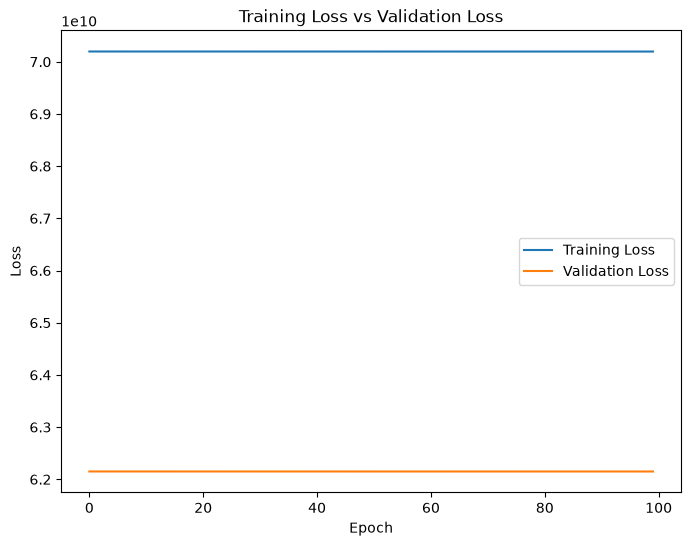

In [65]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
plt.figure(figsize=(8, 6))

plt.plot(history_df['loss'], label='Training Loss')
plt.plot(history_df['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()

## 12. Early Stopping (callback)

- Prevent overfitting
- will not waste the computing power
- save time
  
It is hard to guess exactly how many epochs a model needs. If you train for too few epochs, the model underfits. If you train for too many, it overfits. 

An **Early Stopping Callback** acts as an automatic brake. It monitors the validation loss and automatically stops training once the validation score stops improving, even if you haven't reached your maximum number of epochs. It can also automatically restore the model's best weights!

In [66]:
# configure EarlyStopping parameters
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [67]:
# Use the validation
# Step 1: Define
model_8 = Sequential()
model_8.add(Input(shape=(1,)))
model_8.add(Dense(30, activation='relu'))
model_8.add(Dense(20, activation='relu'))
model_8.add(Dense(15, activation='relu'))
model_8.add(Dense(1, activation='linear'))


# Step 2: Compile 
model_8.compile(loss='mse', metrics=['mae'])


# Step 3: Fit
history = model_8.fit(X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=16,
    callbacks=[es],
    verbose=1
)


Epoch 1/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 70197338112.0000 - mae: 234510.7656 - val_loss: 62150930432.0000 - val_mae: 221361.0625
Epoch 2/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70196592640.0000 - mae: 234509.3125 - val_loss: 62150021120.0000 - val_mae: 221359.1250
Epoch 3/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70195232768.0000 - mae: 234506.6562 - val_loss: 62148333568.0000 - val_mae: 221355.5625
Epoch 4/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70192922624.0000 - mae: 234502.1406 - val_loss: 62145622016.0000 - val_mae: 221349.7969
Epoch 5/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70189391872.0000 - mae: 234495.0938 - val_loss: 62141591552.0000 - val_mae: 221341.1406
Epoch 6/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 70184222720.0000 - mae: 234484.7656 - val_loss: 62135861248.0000 - val_mae: 221328.8438
Epoch 7/300
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 70177153024.0000 - mae: 234470.6562 - val_loss: 62128181248

In [68]:
# Model Weights
model_8.weights

[<Variable path=sequential_9/dense_22/kernel, shape=(1, 30), dtype=float32, value=[[ 2.1998208e+00  5.3253025e-04 -8.0251139e-01  2.4484668e+00
   -9.4425708e-01  2.5488377e+00  2.3058462e+00  2.5901594e+00
    2.6455266e+00 -7.1374273e-01  2.4975059e+00  2.6554499e+00
    2.5203531e+00  2.4703329e+00  2.5618219e+00 -9.0669256e-01
    2.2477491e+00 -1.2797281e-01  2.5748754e+00 -4.6182111e-01
    2.6071997e+00 -9.0959042e-01 -4.7099766e-01  1.6000810e+00
   -7.3732859e-01 -9.6375650e-01  2.5776894e+00 -8.4446305e-01
   -5.8718568e-01 -9.6417415e-01]]>,
 <Variable path=sequential_9/dense_22/bias, shape=(30,), dtype=float32, value=[ 2.9177194  -0.00497441  2.933599    2.9633021   2.908048    2.9863424
   2.9316      3.0084498   3.0457838   2.9411364   2.928416    3.0523386
   2.9677675   2.8732119   2.9956195   2.9209213   2.9105844   2.8896976
   3.0043228   2.9256573   3.024835    2.7136514   2.9659743   2.8985066
   2.92144     2.9021375   2.9445667   2.9118817   2.9489412   2.8999987

In [69]:
# Model Summary
model_8.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                     │ (None, 30)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 20)                  │             620 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,024 (7.91 KB)

 Trainable params: 1,011 (3.95 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,013 (3.96 KB)

In [70]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,7.019734e+10,234510.765625,6.215093e+10,221361.062500
1,7.019659e+10,234509.312500,6.215002e+10,221359.125000
2,7.019523e+10,234506.656250,6.214833e+10,221355.562500
3,7.019292e+10,234502.140625,6.214562e+10,221349.796875
4,7.018939e+10,234495.093750,6.214159e+10,221341.140625
...,...,...,...,...
155,8.596119e+09,63356.687500,6.090452e+09,57347.167969
156,8.600599e+09,63430.187500,6.090315e+09,57345.218750
157,8.589135e+09,63381.671875,6.092244e+09,57395.847656
158,8.598355e+09,63437.332031,6.093840e+09,57444.906250


Text(0, 0.5, 'loss')

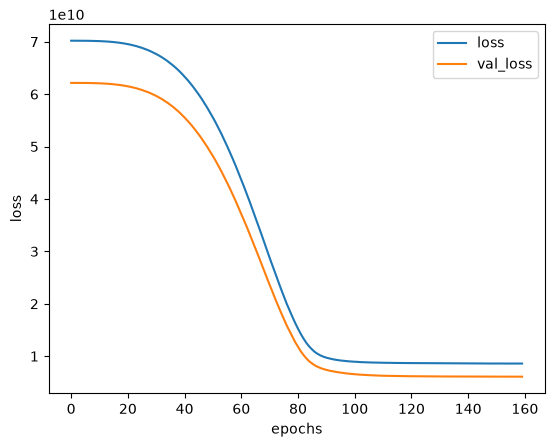

In [71]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss')

## 13.Multi-Feature Neural Network

In [73]:
X = housing[['beds', 'baths', 'sq__ft']]
y = housing['price']

X_train_all, X_test, y_train_all, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_all, y_train_all, test_size=0.20, random_state=42)

ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_val_scaled = ss.transform(X_val)
X_test_scaled = ss.transform(X_test)

In [74]:
# configure EarlyStopping parameters
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [76]:
# Use the validation
# Step 1: Define
model_9 = Sequential([
    Input(shape=(3,)),
    Dense(20,activation='relu'),
    Dense(15,activation='relu'),
    Dense(1, activation='linear')
          ])


# Step 2: Compile 
model_9.compile(loss='mse', metrics=['mae'])


# Step 3: Fit
history = model_9.fit(X_train_scaled,y_train,
                    validation_data=(X_val_scaled,y_val),
                    epochs=50,
                    batch_size=64,
                    callbacks=[es],
                     verbose=1)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 70197854208.0000 - mae: 234511.7031 - val_loss: 62151630848.0000 - val_mae: 221362.4688
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70197714944.0000 - mae: 234511.4219 - val_loss: 62151507968.0000 - val_mae: 221362.1875
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70197592064.0000 - mae: 234511.1875 - val_loss: 62151385088.0000 - val_mae: 221361.9375
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 70197460992.0000 - mae: 234510.9219 - val_loss: 62151270400.0000 - val_mae: 221361.6875
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70197329920.0000 - mae: 234510.6875 - val_loss: 62151163904.0000 - val_mae: 221361.4219
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70197215232.0000 - mae: 234510.4531 - val_loss: 62151053312.0000 - val_mae: 221361.2031
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 70197092352.0000 - mae: 234510.2344 - val_loss: 62150934528.0000 - val_ma

In [77]:
# Model Weights
model_9.weights

[<Variable path=sequential_11/dense_29/kernel, shape=(3, 20), dtype=float32, value=[[-0.36541253  0.37676105 -0.47882345  0.20339815 -0.19214505  0.9040968
    0.26398018  0.30402148 -0.4831867   0.9276069  -0.60771203 -0.01219488
    0.94288874 -0.44110072 -0.7626528   0.5420684   0.8143888  -0.73868346
    0.8935122  -0.7819779 ]
  [-0.329935    0.5378681  -0.7757778   0.4972127  -0.70158744  0.5853962
    0.6272779   0.912442    0.257702    0.50957775 -0.8076395  -0.63603836
    0.04714877 -0.08193768 -0.23097879  0.5224911  -0.14515392 -0.92843693
    0.35063544 -0.7305924 ]
  [-0.7867616   0.49112326 -0.87065315  0.56578344 -0.40555096  0.5049995
    0.13979016  0.5226326   0.5081772   0.5439939  -0.43167245 -0.6399368
    0.39937207 -0.30146074 -0.5567798   0.5888369   0.75590694 -0.41197506
    0.90974116 -0.8370518 ]]>,
 <Variable path=sequential_11/dense_29/bias, shape=(20,), dtype=float32, value=[0.44873133 0.07079349 0.47210646 0.45254827 0.22991405 0.45251048
  0.41849893 0

In [78]:
# Model Summary
model_9.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                     │ (None, 20)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 15)                  │             315 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 1)                   │              16 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 824 (3.22 KB)

 Trainable params: 411 (1.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 413 (1.62 KB)

In [79]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,7.019785e+10,234511.703125,6.215163e+10,221362.468750
1,7.019771e+10,234511.421875,6.215151e+10,221362.187500
2,7.019759e+10,234511.187500,6.215139e+10,221361.937500
3,7.019746e+10,234510.921875,6.215127e+10,221361.687500
4,7.019733e+10,234510.687500,6.215116e+10,221361.421875
5,7.019722e+10,234510.453125,6.215105e+10,221361.203125
6,7.019709e+10,234510.234375,6.215093e+10,221360.937500
7,7.019696e+10,234509.984375,6.215081e+10,221360.687500
8,7.019684e+10,234509.718750,6.215068e+10,221360.421875
9,7.019670e+10,234509.437500,6.215054e+10,221360.125000


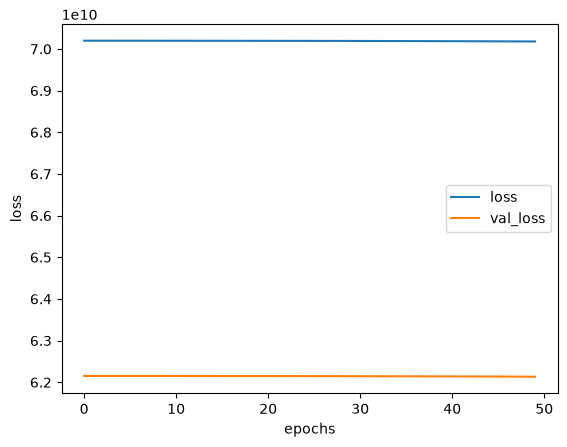

In [81]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
history_df[['loss', 'val_loss']].plot()
plt.xlabel('epochs')
plt.ylabel('loss');